In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/UGC-7596_2_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/UGC-7596_2_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     345   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


In [4]:
image_cut = image[72:172, 0:1890]
image_error_cut = image_error[72:172, 0:1890]

Text(0.5, 0, 'wavelenght')

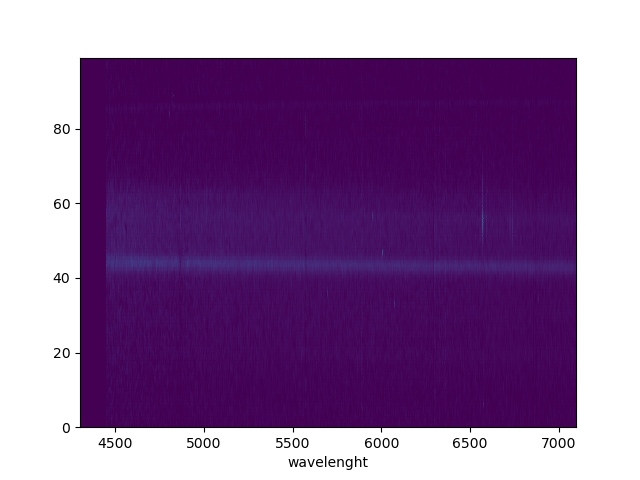

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [6]:
z = 0.00189
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)

Text(0.5, 1.0, 'H$\\alpha$')

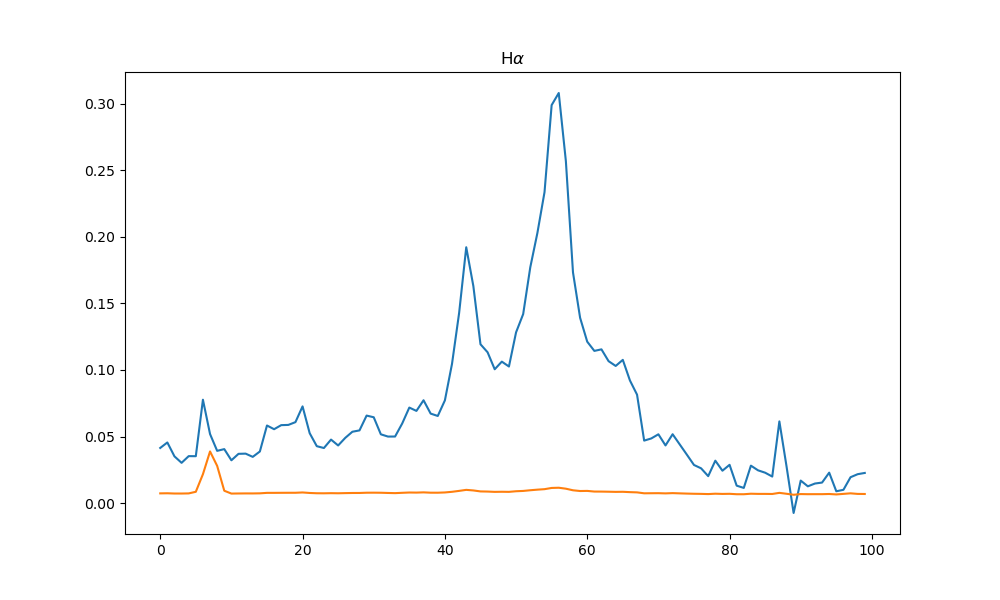

In [7]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')
#fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv", index_col=0)

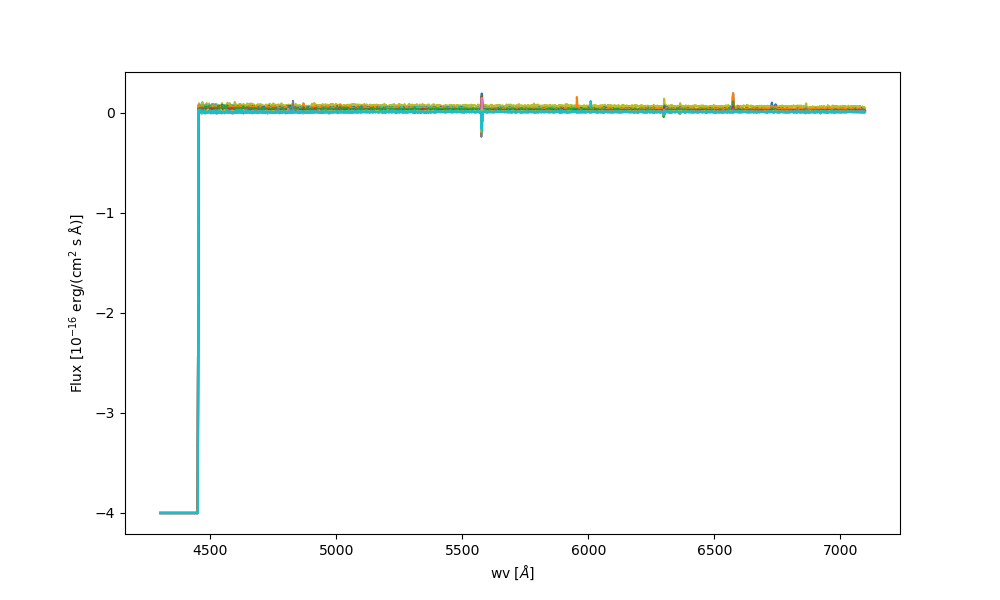

In [8]:
def extraction(x_axes, x_min, x_max, image_cut, image_error_cut):
    mask = (x_axes > x_min)*(x_axes < x_max)
    spectrum = np.sum(image_cut[mask, :], axis = 0)
    spectrum_err = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0))
    return spectrum, spectrum_err

os.makedirs('20ext', exist_ok=True)

spectra =  np.zeros((20, image_cut.shape[1]))
spectra_err = np.zeros((20, image_error_cut.shape[1]))
plt.figure(figsize=(10, 6))
for i in range(20):
    x_min = i * 5
    x_max = x_min + 5
    spectra[i], spectra_err[i] = extraction(x_axes, x_min, x_max, image_cut, image_error_cut)

    plt.plot(wv, spectra[i], label = f'spectrum {i+1}')
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra[i].reshape(-1, 1), spectra_err[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('20ext', f'Spectrum_{i+1}.txt')  # Salva come spectrum_1.txt ... spectrum_20.txt
    np.savetxt(filename, spectrum_table)

## S/N continuum

In [9]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
mask_continuum_2 = (wv > 5100)*(wv < 5400)
mask_continuum_3 = (wv > 5810)*(wv < 6210)
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []
# Calcolo per ogni spettro
for i in range(20):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra[i, mask_continuum_1])
    noise_1 = np.std(spectra[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra[i, mask_continuum_2])
    noise_2 = np.std(spectra[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra[i, mask_continuum_3])
    noise_3 = np.std(spectra[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)
    
# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(20)]
# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)
print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)
# Salvataggio dei file
os.path.join('20ext', 'SNR_20ext_continuum.csv')
df_path_snr = os.path.join('20ext', 'SNR_20ext_continuum.csv')
df_path_signal = os.path.join('20ext', 'Signal_20ext_continuum.csv')
df_path_noise = os.path.join('20ext', 'Noise_20ext_continuum.csv')
df_path_combined = os.path.join('20ext', 'Combined_20ext_continuum.csv')
# Assicurati che la directory esista
os.makedirs('20ext', exist_ok=True)
df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')
print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    1.506735    1.593876    2.072748    2.487238    3.012108   
Continuum_2    2.806704    2.900917    2.996607    4.106030    4.246450   
Continuum_3    2.777242    2.656319    3.261587    3.660698    4.204610   

             Spectrum_6  Spectrum_7  Spectrum_8  Spectrum_9  Spectrum_10  \
Continuum_1    3.089318    3.360359    3.714543    7.837582     6.215521   
Continuum_2    4.169359    4.799274    4.807736    9.396568     7.081559   
Continuum_3    4.323743    3.708773    5.301919   10.930704     4.800201   

             Spectrum_11  Spectrum_12  Spectrum_13  Spectrum_14  Spectrum_15  \
Continuum_1     5.299754     5.774292     4.812568     2.689374     1.766995   
Continuum_2     7.660132     6.876847     5.842298     3.907336     2.398556   
Continuum_3     7.047111     3.731434     5.194593     3.602434     2.643545   

             Spectrum_16  Spectrum_17  Spectrum_18  Spectr

## Redshift

In [10]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter


If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Spettro 1
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 16
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
6279.499999999416   emission              1235
6754.579999999276   emission              1556
6864.099999999244   emission              1630
4522.739999999934 absorption                48
4556.779999999924 absorption                71
4722.539999999875 absorption               183
4726.979999999874 absorption               186
4864.619999999833 absorption               279
5191.699999999737 absorption               500
5575.019999999624 absorption               759
5579.459999999623 absorption               762
5885.819999999532 absorption               969
6261.739999999421 absorption              1223
6297.259999999411 absorption              1247
6550.339999999336 absorption              1418
 6945.49999999922 absorption              1685
Spettro 2
Numero di righe trovate (tu


If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Spettro 9
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 19
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
  4467.97999999995   emission                11
4596.7399999999125   emission                98
5576.4999999996235   emission               760
 5783.699999999562   emission               900
  6300.21999999941   emission              1249
 6363.859999999391   emission              1292
 6864.099999999244   emission              1630
4772.8599999998605 absorption               217
 4863.139999999834 absorption               278
 4870.539999999832 absorption               283
5193.1799999997365 absorption               501
 5575.019999999624 absorption               759
 5579.459999999623 absorption               762
 5720.059999999581 absorption               857
6230.6599999994305 absorption              1202
 6297.259999999411 absorption              1247
6417.1399999993755

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_8876\3765346261.py:37: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f3, ax3 = plt.subplots(figsize=(10,8))

If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Spettro 20
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 8
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
5308.6199999997025   emission               579
 4798.019999999853 absorption               234
 4971.179999999802 absorption               351
5006.6999999997915 absorption               375
 5577.979999999623 absorption               761
 6297.259999999411 absorption              1247
  6301.69999999941 absorption              1250
6708.6999999992895 absorption              1525


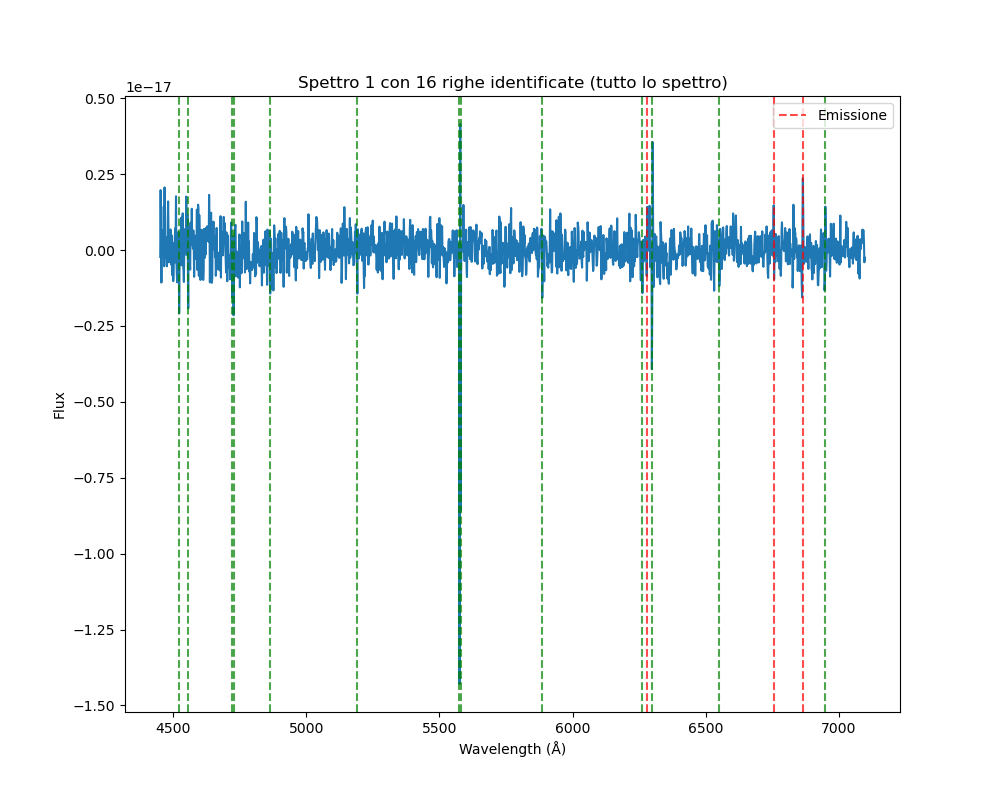

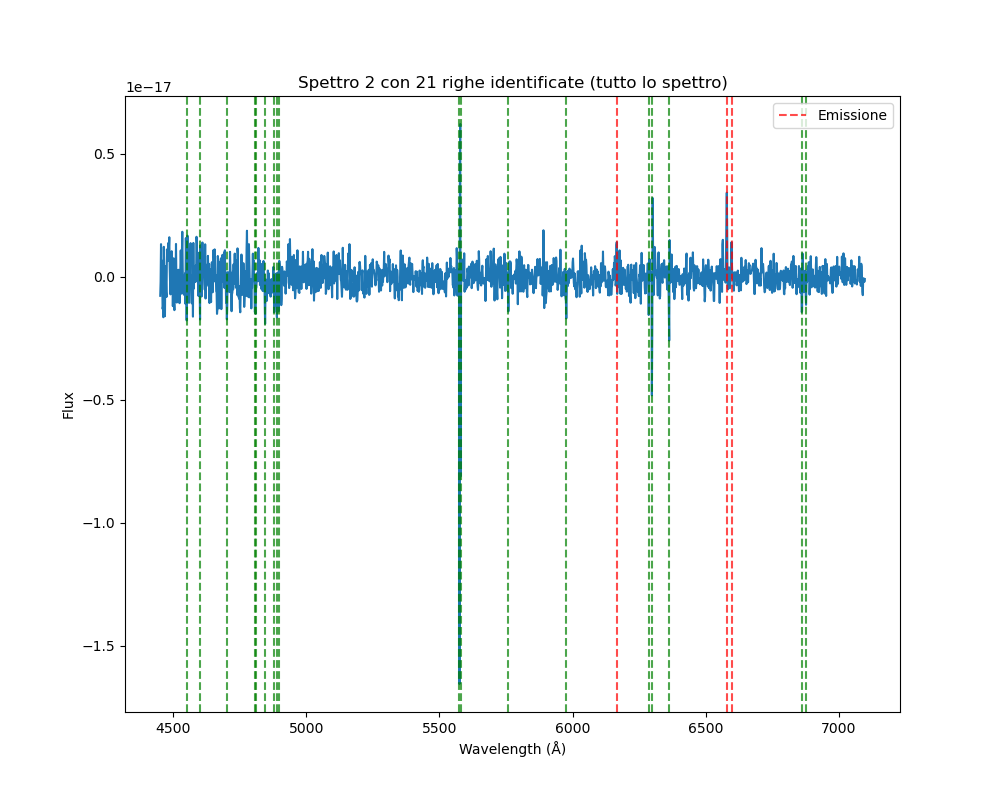

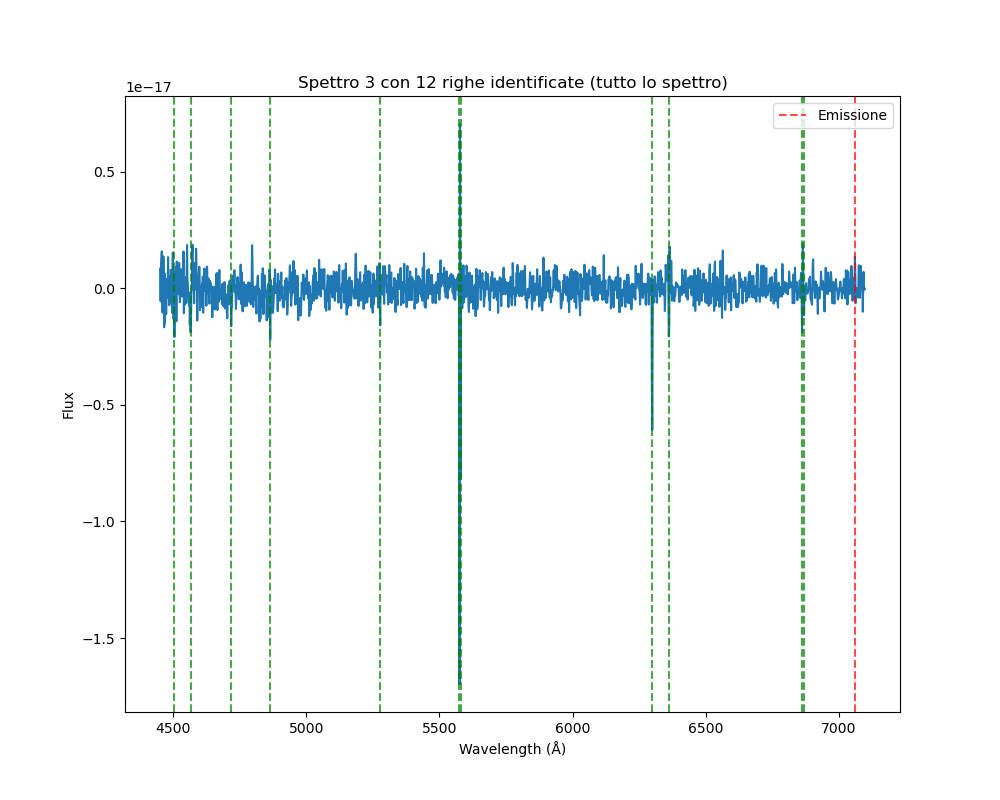

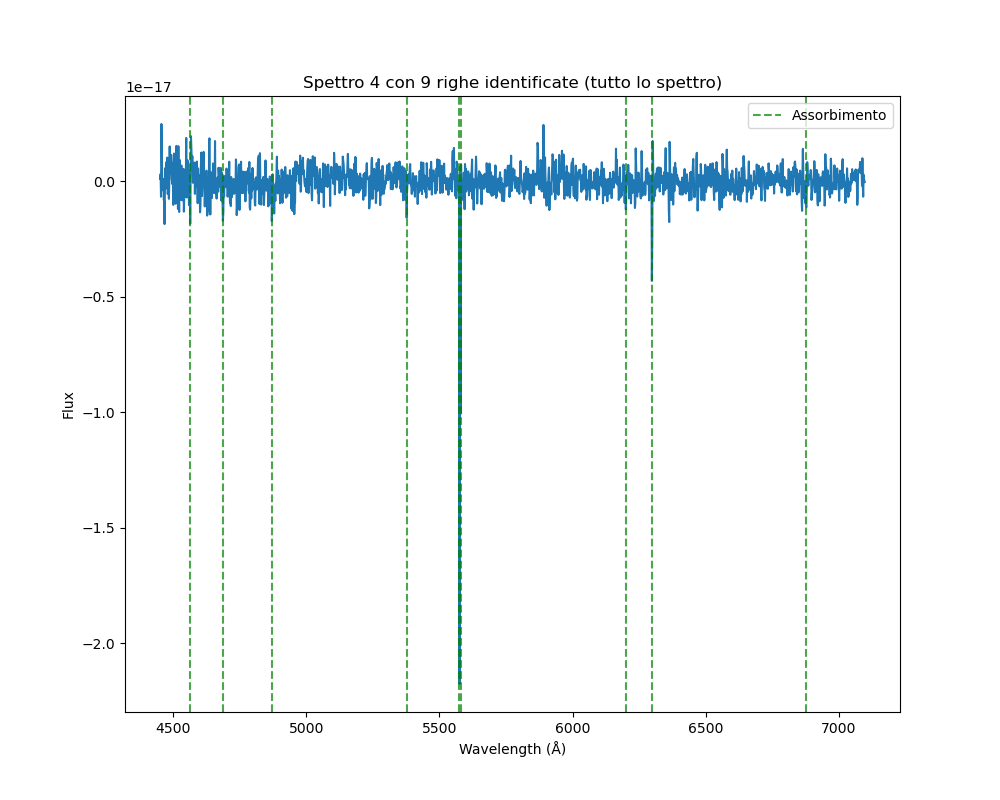

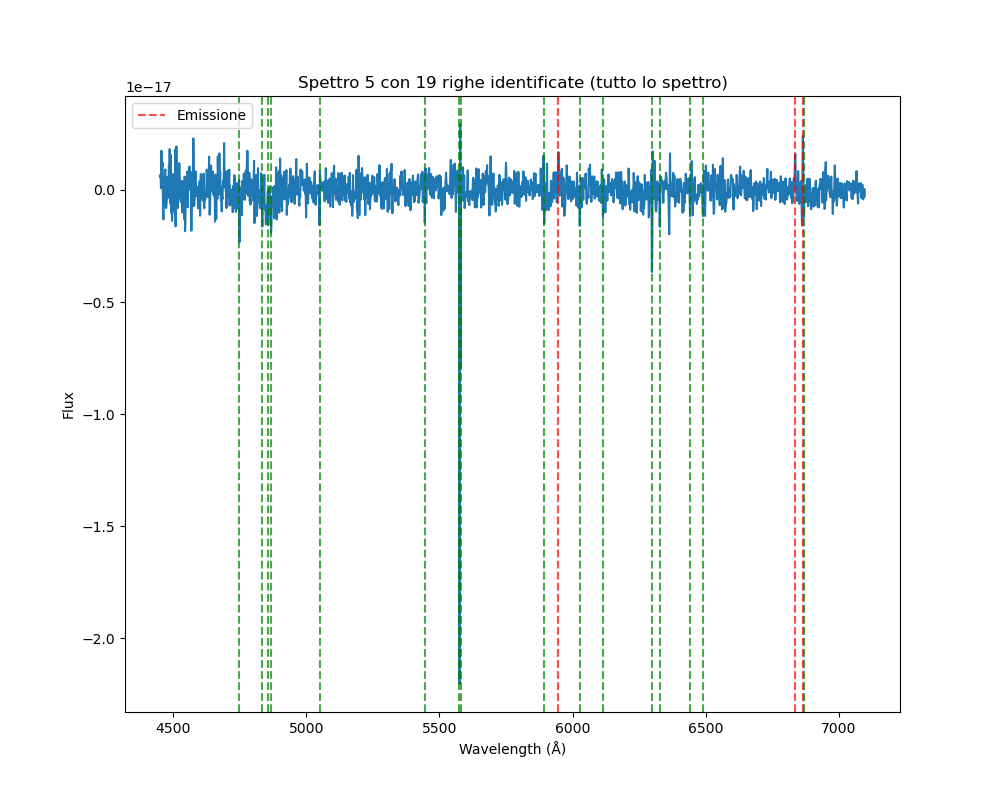

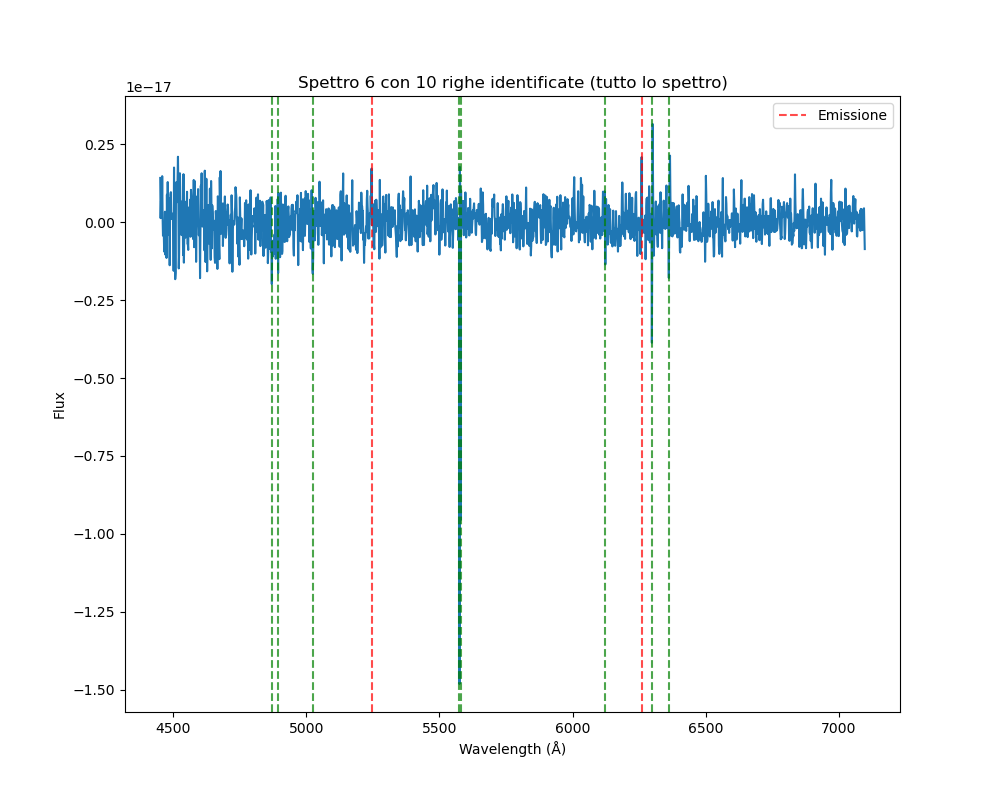

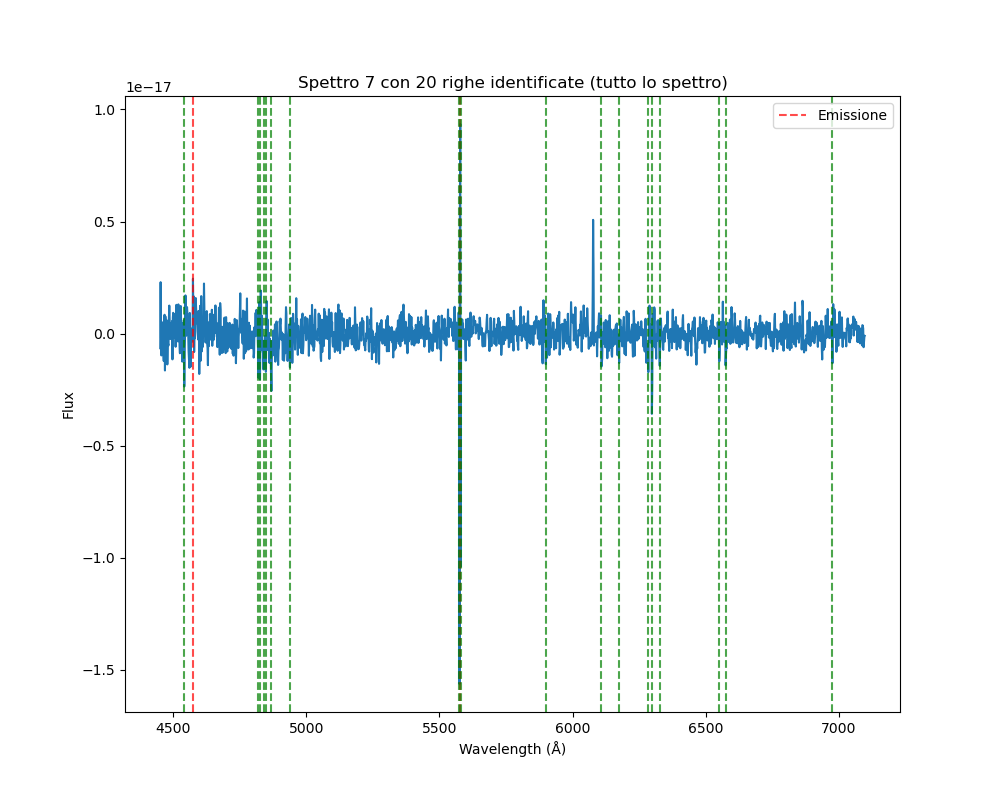

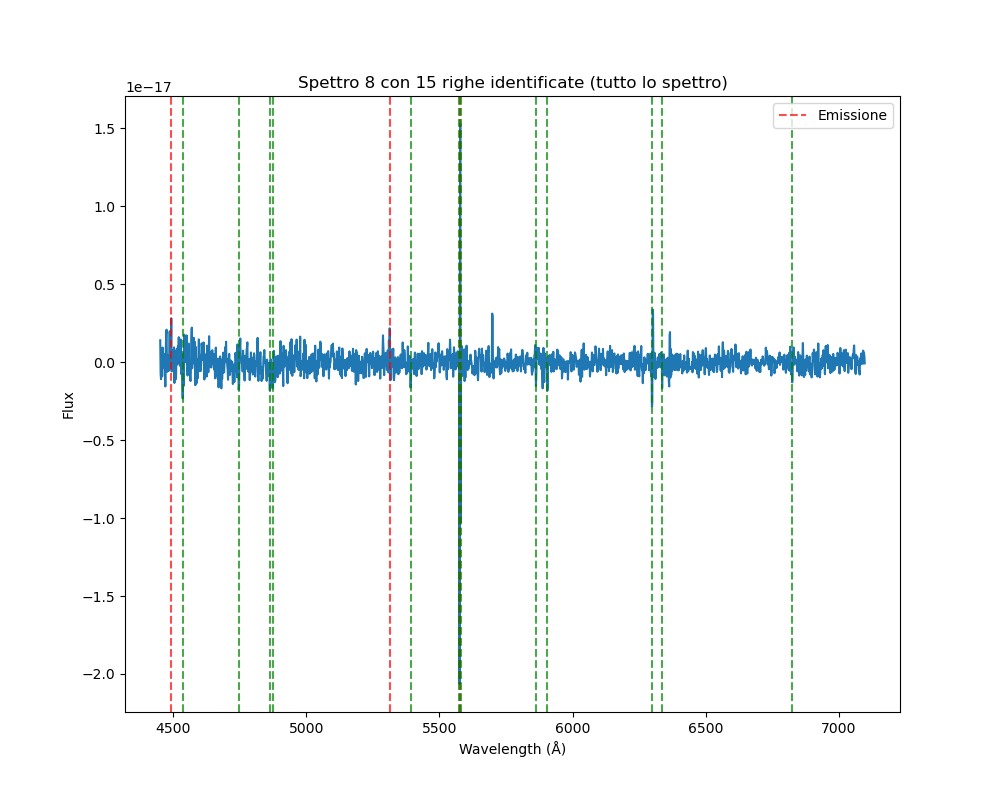

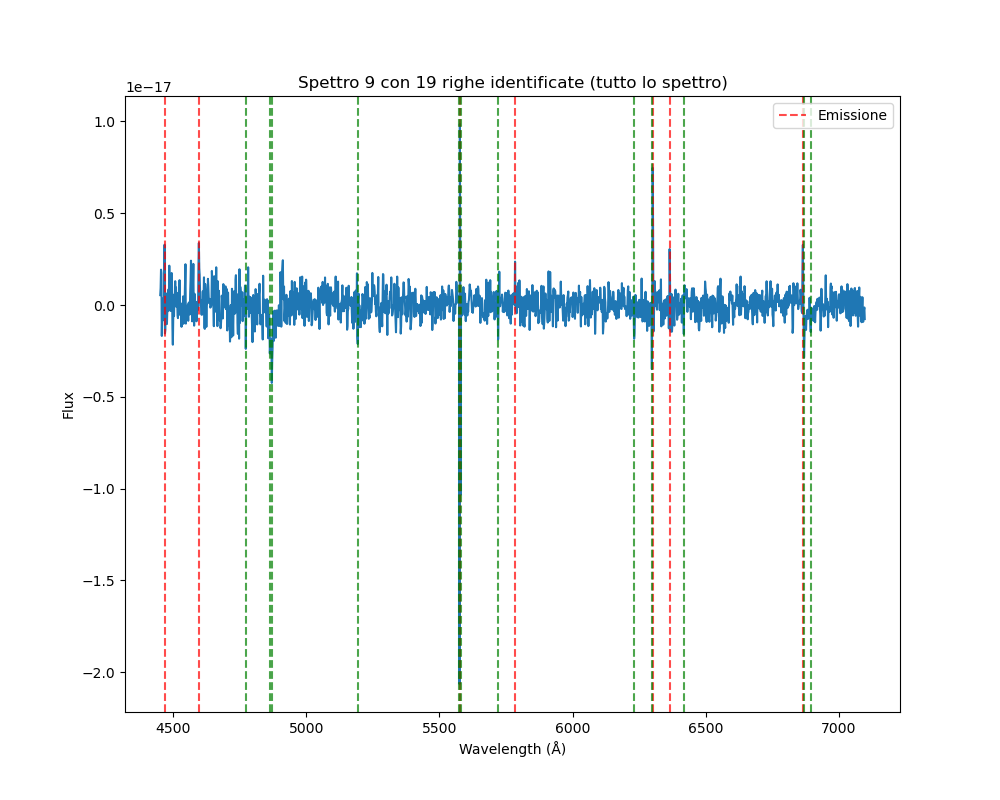

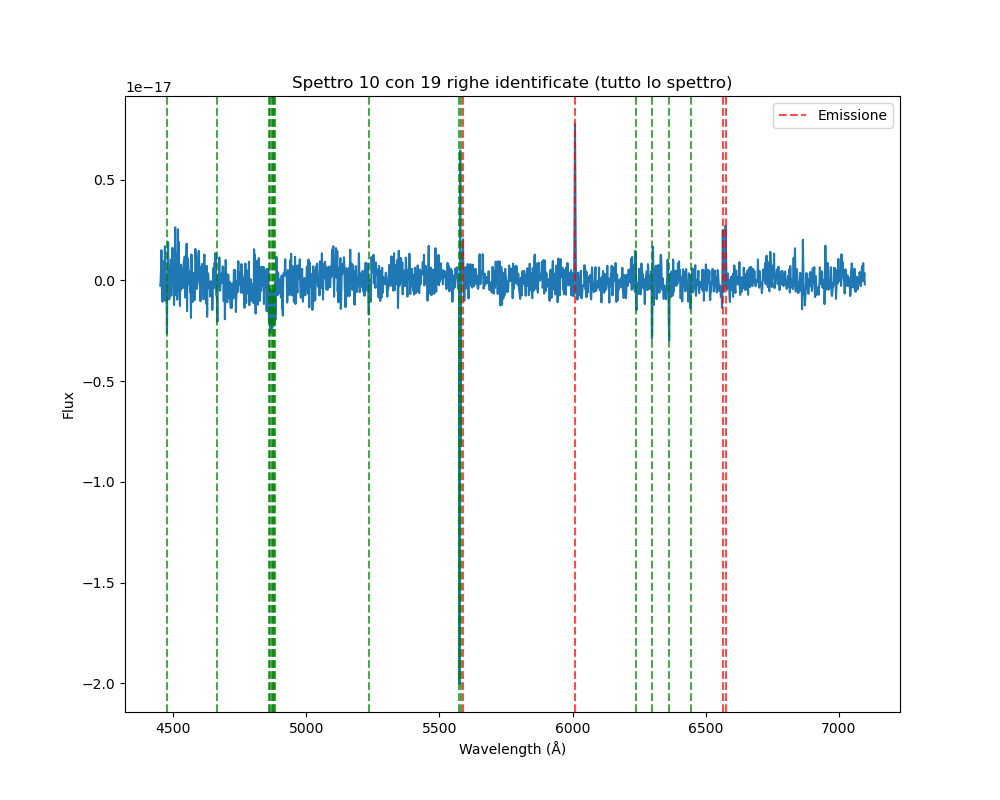

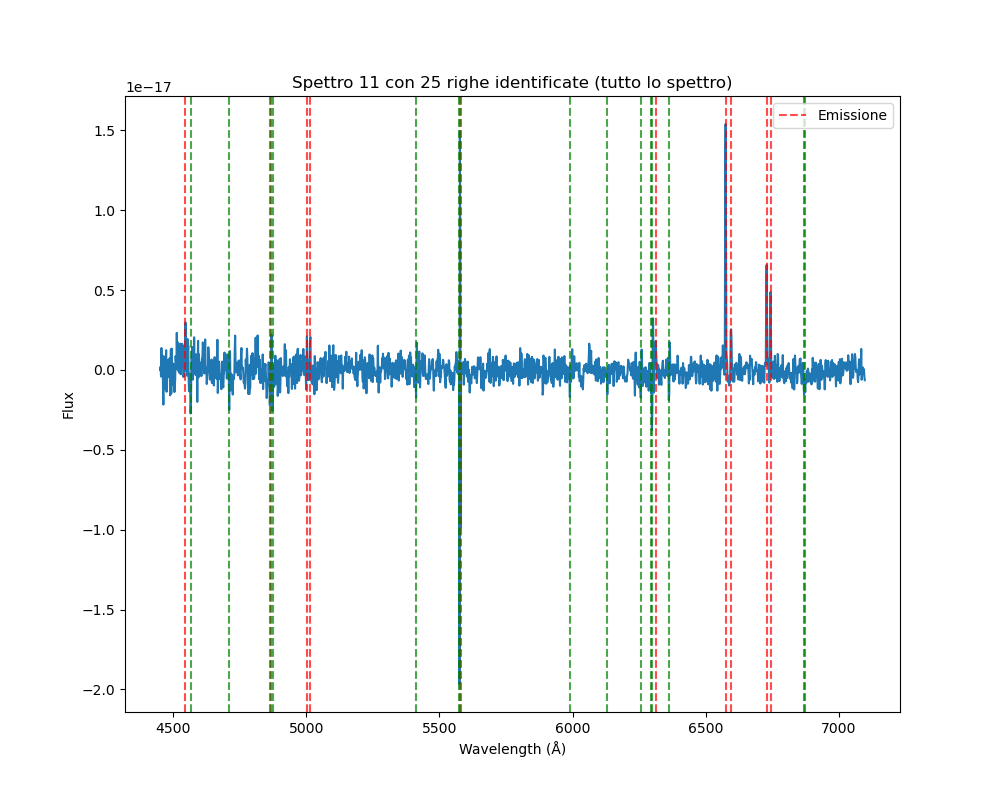

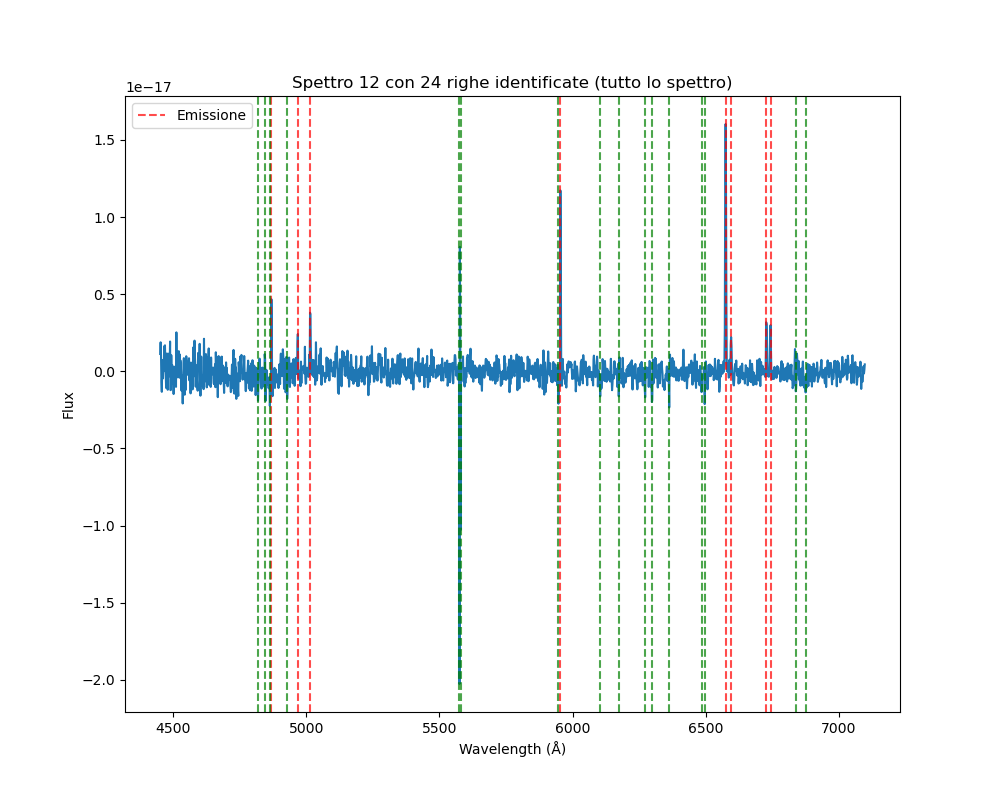

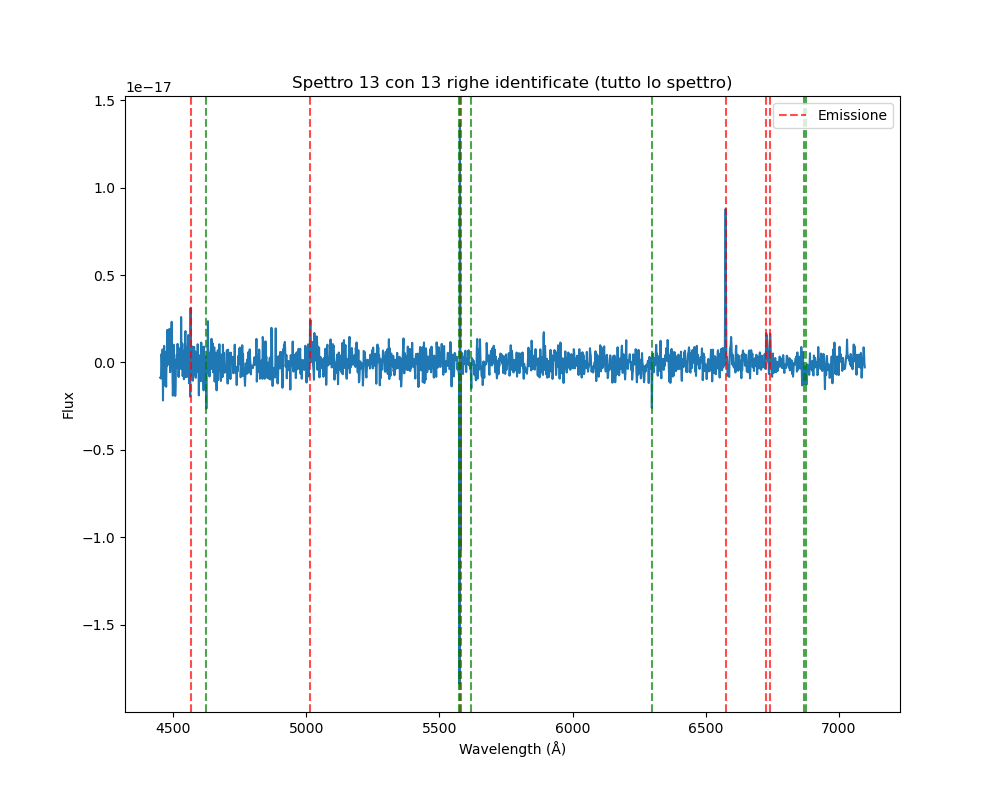

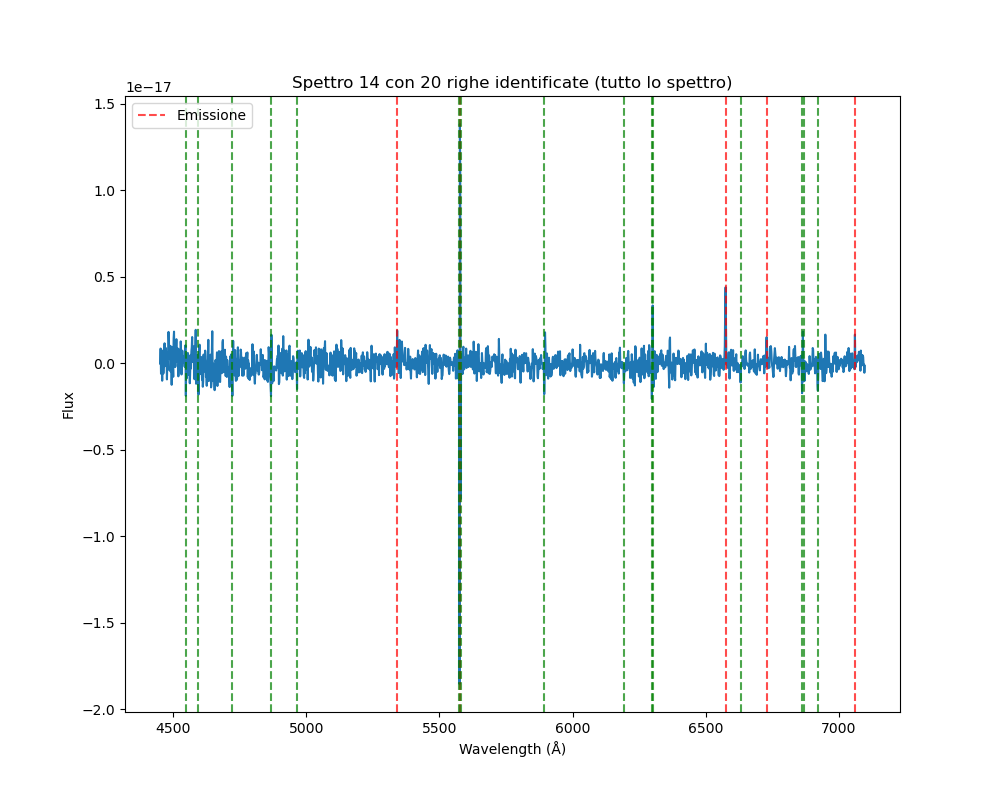

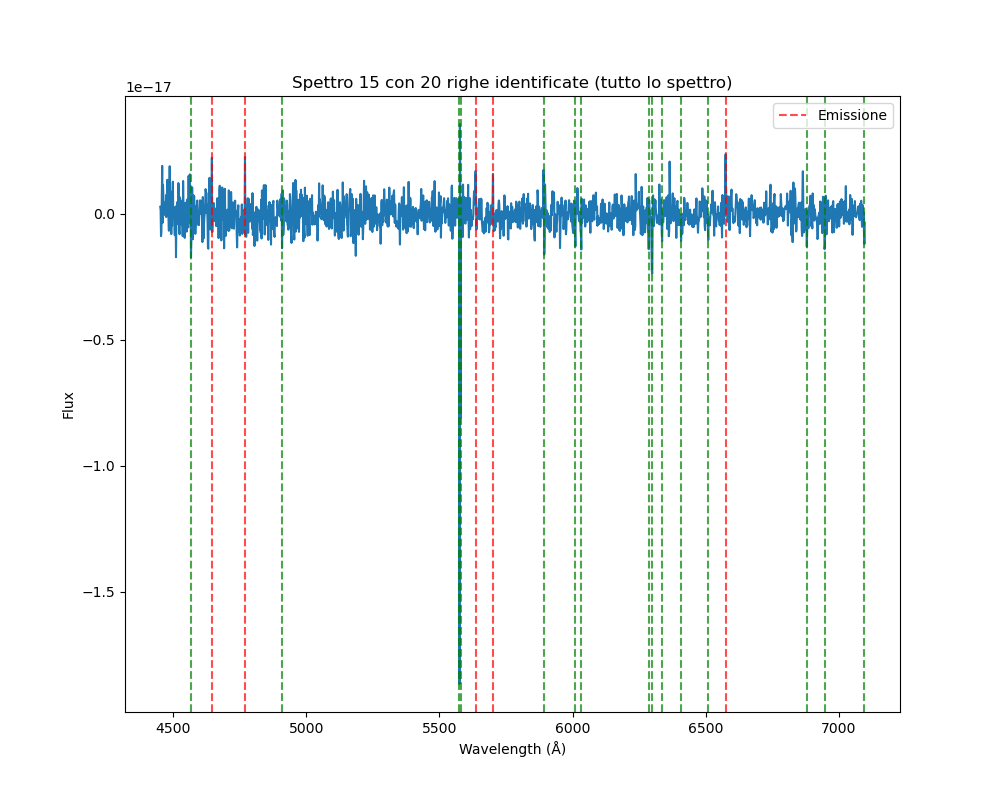

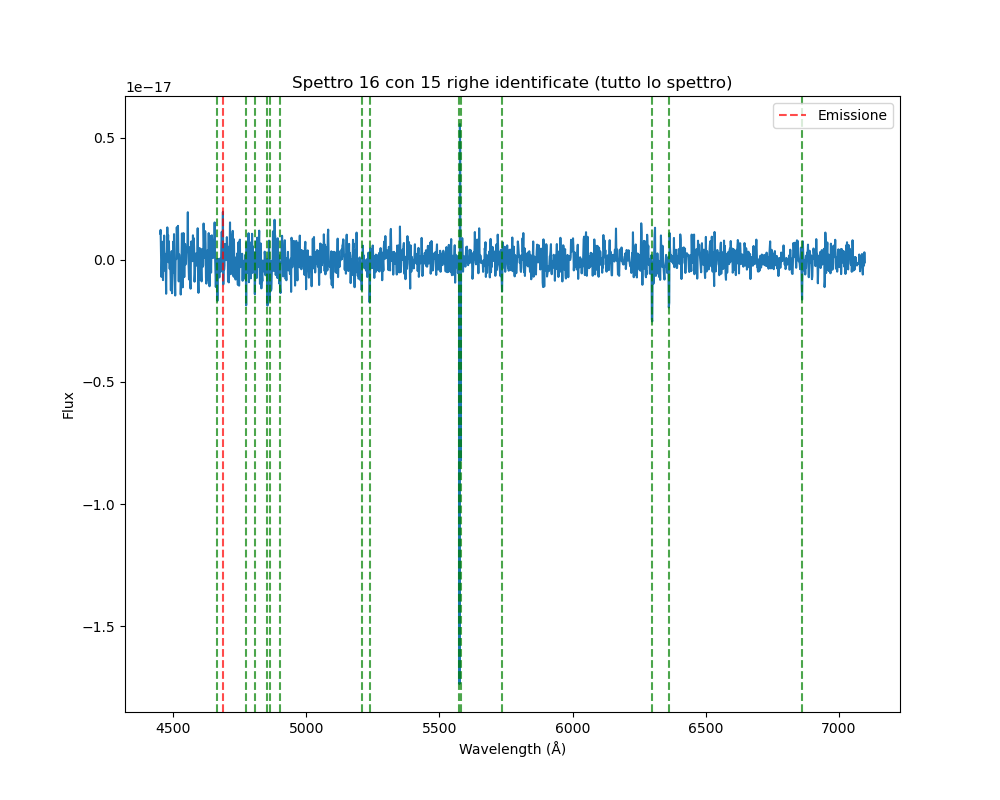

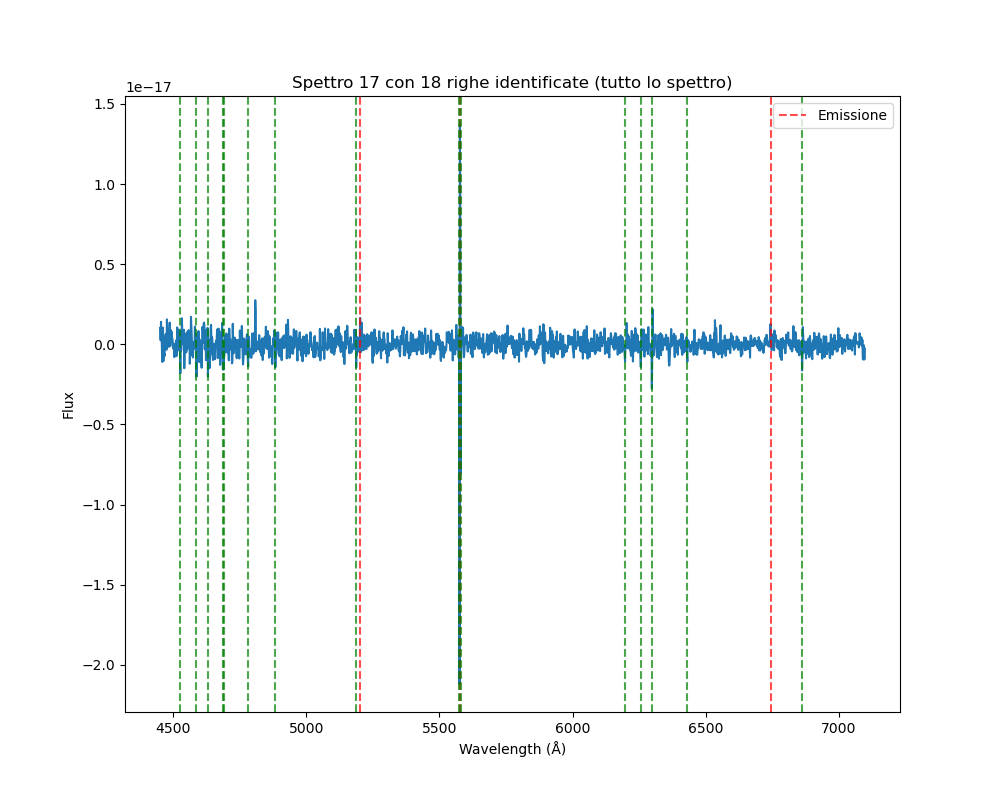

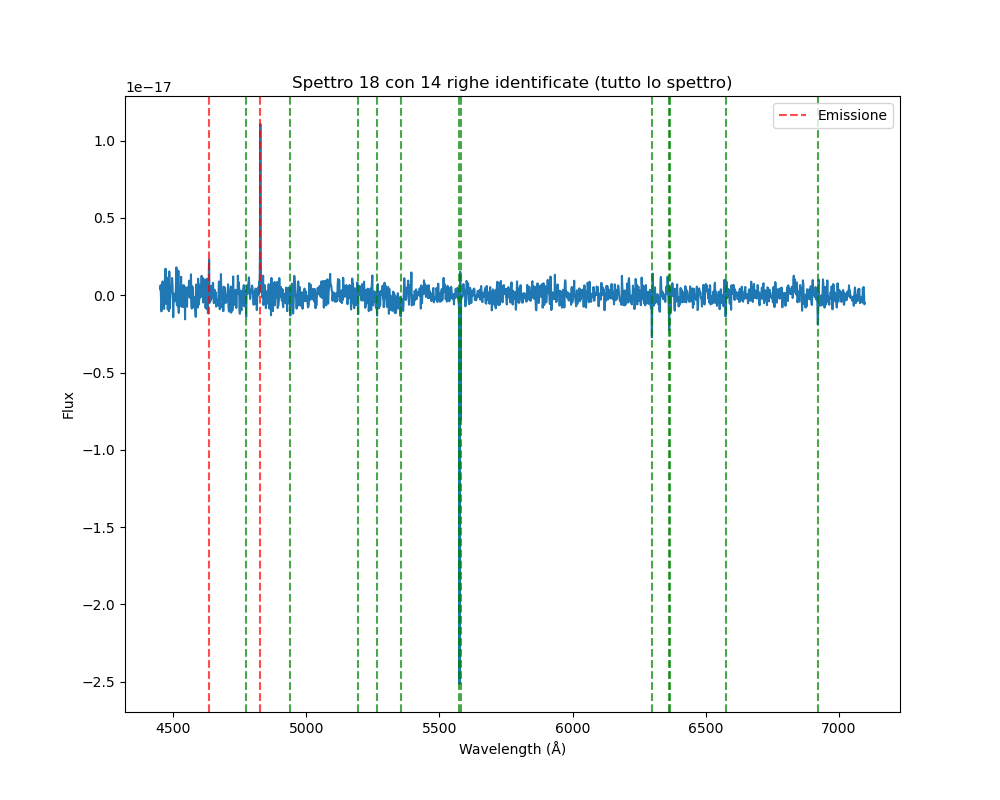

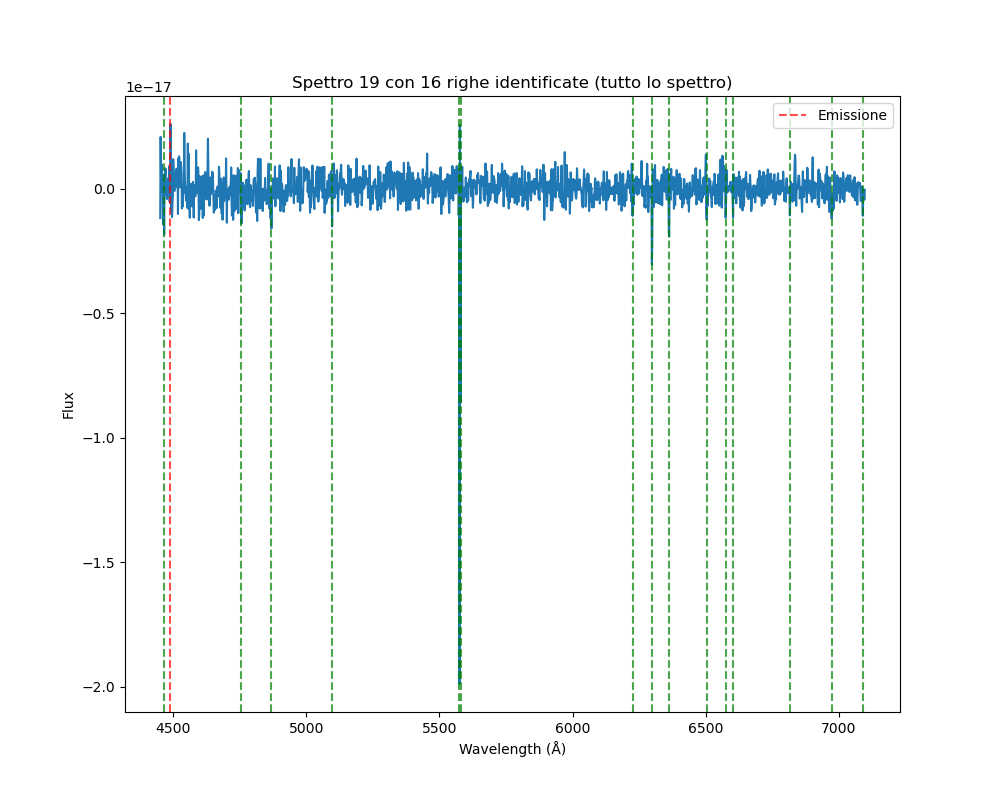

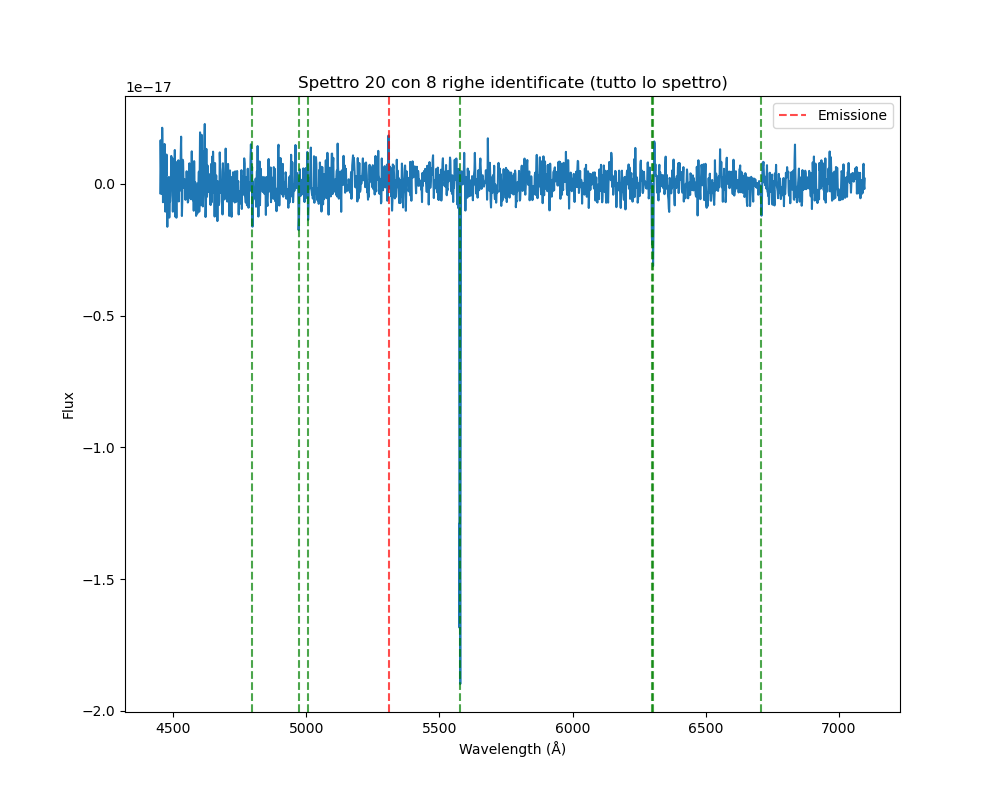

In [11]:
all_lines = []
noise_factor = [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
# Filtra per lunghezze d'onda > 4451 Å
wv_mask = wv > 4451
wv_filtered = wv[wv_mask]

for i in range(20):
    # Applica il filtro anche agli spettri
    spectra_filtered = spectra[i][wv_mask]
    spectra_err_filtered = spectra_err[i][wv_mask]
    
    # Usa lo spettro filtrato per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux = spectra_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv_filtered * u.Angstrom)
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    
    # Crea lo spettro per TUTTO il range filtrato (senza ritagliare i bordi)
    spectrum_no_continuum_full = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux=flux_continuum_subtracted,
        uncertainty=StdDevUncertainty(spectra_err_filtered * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe su TUTTO lo spettro filtrato (senza escludere i bordi)
    lines = find_lines_threshold(spectrum_no_continuum_full, noise_factor = noise_factor[i])
    print('Spettro', i+1)
    print(f"Numero di righe trovate (tutto lo spettro, wv > 4451 Å): {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv_filtered, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            # Trova l'indice corrispondente nel flux per determinare il tipo di riga
            line_idx = np.argmin(np.abs(wv_filtered - line_pos.value))
            
            # Determina se è emissione (positiva) o assorbimento (negativa)
            if flux_continuum_subtracted[line_idx].value > 0:
                # Riga di emissione - colore rosso
                ax3.axvline(x=line_pos.value, color='red', alpha=0.7, linestyle='--', 
                           label='Emissione' if line_pos == lines['line_center'][0] else "")
            else:
                # Riga di assorbimento - colore verde
                ax3.axvline(x=line_pos.value, color='green', alpha=0.7, linestyle='--',
                           label='Assorbimento' if line_pos == lines['line_center'][0] else "")
    
    ax3.legend()
    ax3.set_title(f"Spettro {i+1} con {len(lines)} righe identificate (tutto lo spettro)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [13]:
6864/(1+z)

6851.051512641108

In [17]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6
l_OI = 6300.3

#lines_1 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_2 = [l_HA, l_NII_2]
#lines_3 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
#lines_4 = [l_HB, l_OIII_1, l_OIII_2, l_He_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
#lines_5 = [l_HB, l_OIII_1, l_OIII_2, l_He_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
#lines_6 = [l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
#lines_7 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
#lines_8 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
#lines_9 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_10 = [l_NII_1, l_HA]
lines_11 = [l_HB, l_OIII_2, l_OI, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_12 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_13 = [l_OIII_2, l_HA, l_SII_1, l_SII_2]
lines_14 = [l_HB, l_HA, l_SII_1]
#lines_15 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
#lines_16 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
#lines_17 = [l_HB, l_HA, l_SII_1]
#lines_18 = [l_HA, l_SII_1]
#lines_19 = [l_HB, l_HA, l_NII_2, l_SII_1, l_SII_2]
#lines_20 = [l_HB, l_HA, l_NII_2, l_SII_1, l_SII_2]

#lines_spectrum_1 = all_lines[0]['line_center'] 
lines_spectrum_2 = [6579.9399999993275, 6596.219999999323]
#lines_spectrum_3 = all_lines[2]['line_center'] 
#lines_spectrum_4 = all_lines[3]['line_center'] 
#lines_spectrum_5 = all_lines[4]['line_center'] 
#lines_spectrum_6 = all_lines[5]['line_center'] 
#lines_spectrum_7 = all_lines[6]['line_center'] 
#lines_spectrum_8 = [4876.45999999983, 4974.139999999801, 5021.499999999787, 6582.899999999327, 6603.6199999993205, 6736.819999999281, 6751.619999999277]
#lines_spectrum_9 = [4876.45999999983, 4974.139999999801, 5021.499999999787, 6582.899999999327, 6603.6199999993205, 6736.819999999281, 6751.619999999277]
lines_spectrum_10 = [6563.659999999332, 6574.019999999329]
lines_spectrum_11 = [4869.059999999832, 5015.579999999789,6312.0599999994065, 6574.019999999329, 6594.739999999323, 6727.939999999284,6742.7399999992795]
lines_spectrum_12 = [ 4869.059999999832, 4968.219999999803, 5014.099999999789, 6574.019999999329, 6594.739999999323, 6726.459999999284,6742.7399999992795]
lines_spectrum_13 = [5015.579999999789, 6574.019999999329, 6726.459999999284, 6741.25999999928]
lines_spectrum_14 = [4867.579999999833, 6574.019999999329, 6727.939999999284]
#lines_spectrum_15 = [4869.059999999832, 5014.099999999789, 6574.019999999329, 6594.739999999323, 6727.939999999284,  6739.77999999928]
#lines_spectrum_16 = all_lines[15]['line_center']
#lines_spectrum_17 = [4869.059999999832, 6572.53999999933, 6726.459999999284]
#lines_spectrum_18 = [6572.53999999933, 6726.459999999284]
#lines_spectrum_19 = [4869.059999999832, 6572.53999999933, 6593.259999999324, 6726.459999999284,  6741.25999999928]
#lines_spectrum_20 = [4869.059999999832, 6574.019999999329, 6594.739999999323, 6726.459999999284,  6741.25999999928]

def redshift(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i].value / lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
def redshift_hand(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i]/ lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
#z_1_mean, z_1_std = redshift(lines_1, lines_spectrum_1)    
z_2_mean, z_2_std = redshift_hand(lines_2, lines_spectrum_2)    
#z_3_mean, z_3_std = redshift(lines_3, lines_spectrum_3)    
#z_4_mean, z_4_std = redshift(lines_4, lines_spectrum_4)
#z_5_mean, z_5_std = redshift(lines_5, lines_spectrum_5) 
#z_6_mean, z_6_std = redshift(lines_6, lines_spectrum_6) 
#z_7_mean, z_7_std = redshift(lines_7, lines_spectrum_7) 
#z_8_mean, z_8_std = redshift_hand(lines_8, lines_spectrum_8) 
#z_9_mean, z_9_std = redshift_hand(lines_9, lines_spectrum_9) 
z_10_mean, z_10_std = redshift_hand(lines_10, lines_spectrum_10) 
z_11_mean, z_11_std = redshift_hand(lines_11, lines_spectrum_11) 
z_12_mean, z_12_std = redshift_hand(lines_12, lines_spectrum_12) 
z_13_mean, z_13_std = redshift_hand(lines_13, lines_spectrum_13) 
z_14_mean, z_14_std = redshift_hand(lines_14, lines_spectrum_14) 
#z_15_mean, z_15_std = redshift_hand(lines_15, lines_spectrum_15)
#z_16_mean, z_16_std = redshift(lines_16, lines_spectrum_16) 
#z_17_mean, z_17_std = redshift_hand(lines_17, lines_spectrum_17)
#z_18_mean, z_18_std = redshift_hand(lines_18, lines_spectrum_18) 
#z_19_mean, z_19_std = redshift_hand(lines_19, lines_spectrum_19)
#z_20_mean, z_20_std = redshift_hand(lines_20, lines_spectrum_20) 

z = [np.nan, z_2_mean, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, z_10_mean, z_11_mean, z_12_mean, z_13_mean, z_14_mean, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
z_err =  [np.nan, z_2_std, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, z_10_std, z_11_std, z_12_std, z_13_std, z_14_std, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]

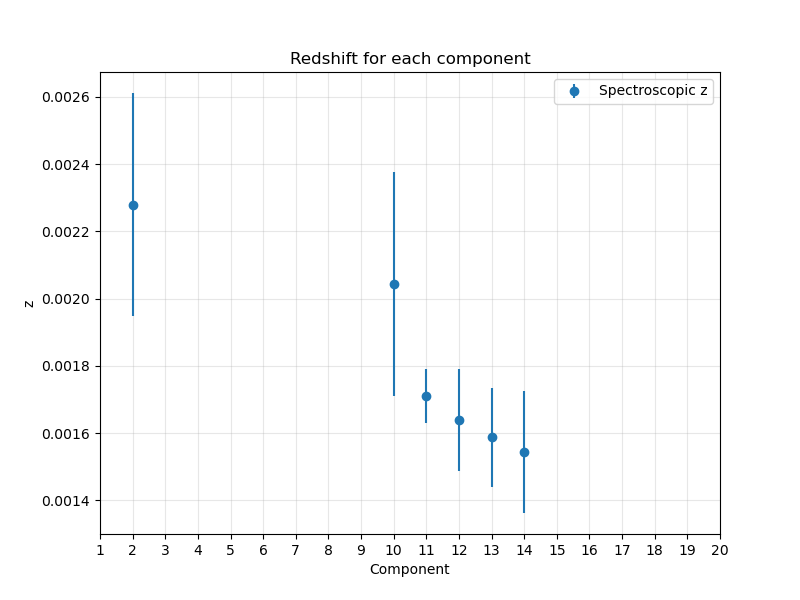

In [18]:
plt.figure(figsize=(8, 6))
comp = np.arange(1, 21, 1)
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
#plt.axhline(0.01505 , color = 'red', label = 'Tabulated z')
plt.title('Redshift for each component')
plt.legend()
plt.savefig('Redshift_grad', bbox_inches='tight')
plt.grid(alpha = 0.3)

red_table = np.column_stack((z, z_err))
np.savetxt('redshift_grad.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')

## S/N emission lines 

In [19]:
z = [0.00189, z_2_mean, 0.00189, 0.00189, 0.00189, 0.00189, 0.00189, 0.00189, 0.00189, z_10_mean, z_11_mean, z_12_mean, z_13_mean, z_14_mean, 0.00189, 0.00189, 0.00189, 0.00189, 0.00189, 0.00189]

In [20]:
def SNR_line(wv, wv_line, spectrum): 
    left_region = (wv > wv_line-15)*(wv < wv_line-5) 
    right_region = (wv > wv_line+5)*(wv < wv_line+15) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectrum[mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise
    
def SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectrum):
    
    left_region = (wv > OIII_1-15)*(wv < OIII_1-5) 
    right_region = (wv > OIII_2+5)*(wv < OIII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 
    
def SNR_SII_line(wv, SII_1, SII_2, wv_line, spectrum):
    
    left_region = (wv > SII_1-15)*(wv < SII_1-5) 
    right_region = (wv > SII_2+5)*(wv < SII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectrum):
    
    left_region = (wv > NII_1-15)*(wv < NII_1-5) 
    right_region = (wv > NII_2+5)*(wv < NII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def save_spectral_data(snr, signal, noise, line_name, output_dir='20ext', num_spectra=20):
    
    data = np.concatenate([
        np.array(snr).reshape(-1, 1),
        np.array(signal).reshape(-1, 1),
        np.array(noise).reshape(-1, 1)
    ], axis=1)

    df = pd.DataFrame(
        data, 
        columns=['SNR', 'Signal', 'Noise'],
        index=[f'Spettro_{i+1}' for i in range(num_spectra)]
    )
    
    df_path = os.path.join(output_dir, f'SNR_{line_name}.csv')
    df.to_csv(df_path, float_format='%.3f')
    print(df)
    return df_path

In [21]:
SNR_HB = np.zeros(20)
signal_HB = np.zeros(20)
noise_HB = np.zeros(20)
SNR_SII_1 = np.zeros(20)
signal_SII_1 = np.zeros(20)
noise_SII_1 = np.zeros(20)
SNR_SII_2 = np.zeros(20)
signal_SII_2 = np.zeros(20)
noise_SII_2 = np.zeros(20)
SNR_NII_1 = np.zeros(20)
signal_NII_1 = np.zeros(20)
noise_NII_1 = np.zeros(20)
SNR_NII_2 = np.zeros(20)
signal_NII_2 = np.zeros(20)
noise_NII_2 = np.zeros(20)
SNR_HA = np.zeros(20)
signal_HA = np.zeros(20)
noise_HA = np.zeros(20)
SNR_OIII_1 = np.zeros(20)
signal_OIII_1 = np.zeros(20)
noise_OIII_1 = np.zeros(20)
SNR_OIII_2 = np.zeros(20)
signal_OIII_2 = np.zeros(20)
noise_OIII_2 = np.zeros(20)

for i in range(20):
    if np.isnan(z[i]) == False: 
        l_Hgam = 4340.5*(1+z[i])
        l_HA = 6562.8*(1+z[i])
        l_HB = 4861.3*(1+z[i])
        l_NII_1 = 6548.1*(1+z[i])
        l_NII_2 = 6583.4*(1+z[i])
        l_SII_1 = 6717.0*(1+z[i])
        l_SII_2 = 6731.3*(1+z[i])
        l_OIII_1 = 4958.9*(1+z[i])
        l_OIII_2 = 5006.8*(1+z[i])
        l_He_1 = 5875.6*(1+z[i])
        SNR_HB[i], signal_HB[i], noise_HB[i] = SNR_line(wv, l_HB, spectra[i])
        SNR_SII_1[i], signal_SII_1[i], noise_SII_1[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_1, spectra[i])
        SNR_SII_2[i], signal_SII_2[i], noise_SII_2[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_2, spectra[i])
        SNR_NII_1[i], signal_NII_1[i], noise_NII_1[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_1, spectra[i])
        SNR_NII_2[i], signal_NII_2[i], noise_NII_2[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_2, spectra[i])
        SNR_HA[i], signal_HA[i], noise_HA[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_HA, spectra[i])
        SNR_OIII_1[i], signal_OIII_1[i], noise_OIII_1[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_1, spectra[i])
        SNR_OIII_2[i], signal_OIII_2[i], noise_OIII_2[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_2, spectra[i])
    else:
        SNR_HB[i] = np.nan
        signal_HB[i] = np.nan
        noise_HB[i] = np.nan
        SNR_SII_1[i] = np.nan 
        signal_SII_1[i] = np.nan 
        noise_SII_1[i] = np.nan 
        SNR_SII_2[i] = np.nan 
        signal_SII_2[i] = np.nan 
        noise_SII_2[i] = np.nan 
        SNR_NII_1[i] = np.nan 
        signal_NII_1[i] = np.nan 
        noise_NII_1[i] = np.nan 
        SNR_NII_2[i] = np.nan 
        signal_NII_2[i] = np.nan 
        noise_NII_2[i] = np.nan 
        SNR_HA[i] = np.nan 
        signal_HA[i] = np.nan 
        noise_HA[i] = np.nan 
        SNR_OIII_1[i] = np.nan 
        signal_OIII_1[i] = np.nan 
        noise_OIII_1[i] = np.nan 
        SNR_OIII_2[i] = np.nan 
        signal_OIII_2[i] = np.nan
        noise_OIII_2[i] = np.nan
        
save_spectral_data(SNR_HB, signal_HB, noise_HB, 'HB')
save_spectral_data(SNR_SII_1, signal_SII_1, noise_SII_1, 'SII_1')
save_spectral_data(SNR_SII_2, signal_SII_2, noise_SII_2, 'SII_2')
save_spectral_data(SNR_NII_1, signal_NII_1, noise_NII_1, 'NII_1')
save_spectral_data(SNR_NII_2, signal_NII_2, noise_NII_2, 'NII_2')
save_spectral_data(SNR_HA, signal_HA, noise_HA, 'HA')
save_spectral_data(SNR_OIII_1, signal_OIII_1, noise_OIII_1, 'OIII_1')
save_spectral_data(SNR_OIII_2, signal_OIII_2, noise_OIII_2, 'OIII_2')

                 SNR    Signal     Noise
Spettro_1  -1.517305 -0.035940  0.023687
Spettro_2  -0.127191 -0.001817  0.014283
Spettro_3  -0.819004 -0.022209  0.027117
Spettro_4  -1.204770 -0.017847  0.014814
Spettro_5  -1.752837 -0.032092  0.018308
Spettro_6  -1.637868 -0.033073  0.020193
Spettro_7  -2.836760 -0.048966  0.017261
Spettro_8  -1.203377 -0.024662  0.020494
Spettro_9  -3.884961 -0.102704  0.026436
Spettro_10 -0.619109 -0.019603  0.031663
Spettro_11  2.501704  0.067055  0.026804
Spettro_12  6.152040  0.126371  0.020541
Spettro_13  6.683879  0.078164  0.011694
Spettro_14  0.116199  0.002144  0.018454
Spettro_15  0.957061  0.014504  0.015155
Spettro_16 -1.119041 -0.033926  0.030317
Spettro_17 -1.351937 -0.030741  0.022739
Spettro_18 -0.052989 -0.000885  0.016706
Spettro_19 -1.882215 -0.033754  0.017933
Spettro_20 -1.096996 -0.019073  0.017386
                  SNR    Signal     Noise
Spettro_1    0.732247  0.013328  0.018202
Spettro_2    0.238405  0.003235  0.013569
Spettro_3   -

'20ext\\SNR_OIII_2.csv'

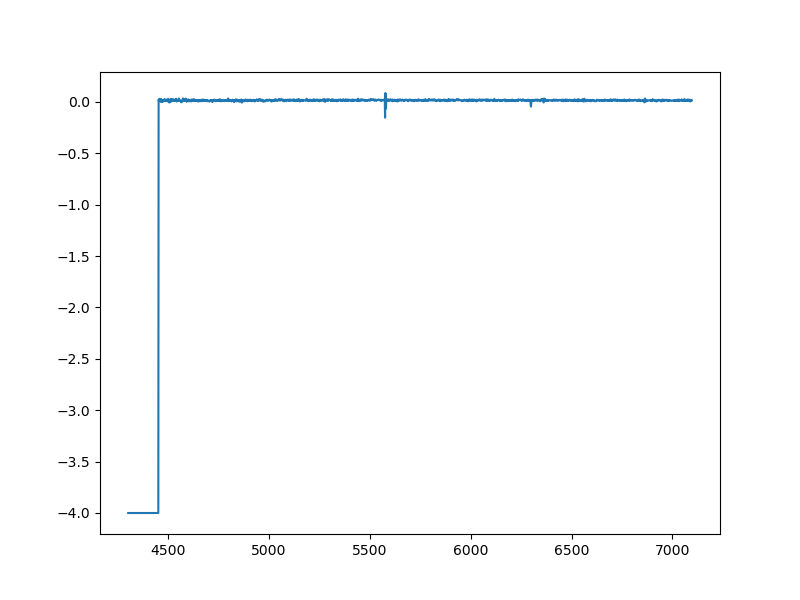

In [22]:
plt.figure(figsize = (8, 6))
plt.plot(wv, spectra[2])

In [29]:
l_OIII_2

5163.241907016047